In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import warnings; warnings.simplefilter('ignore')
import spatialdata as sd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import senepy as sp
from typing import Optional, Tuple, Literal
import math
# import decoupler as dc



/home/lallen2/miniforge3/envs/spatial-clean/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


'/fh/fast/grady_w/users/lallen2/spatial/trio-tma-xenium/TRIO-TMA-WORKFLOW'

In [ ]:
import sys
from pathlib import Path

# Locate project root (folder containing config.yaml) and add scripts/ to sys.path
_p = Path.cwd().resolve()
while not (_p / 'config.yaml').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p / 'scripts'))
from paths import P, ensure_dirs

In [2]:
epi_adata = sc.read_h5ad(str(P.processed.adata.epithelial / "epithelial_20_50_harmony_batch_05_pt_05_ssg.h5ad"))


# setup

In [3]:
# ── 1. Check for cores with minority labels < 10 cells ───────────────────────
epi_obs = epi_adata.obs[epi_adata.obs["annotation_final_coarse"] == "Epithelial"]

for col in ["tissue_type_cell_level", "tissue_type_dysplasia_cell_level"]:
    print(f"\n=== {col} ===")
    counts = epi_obs.groupby(["core_id", col]).size().reset_index(name="n_cells")
    core_label_counts = counts.groupby("core_id").filter(lambda x: len(x) > 1)  # only mixed cores
    small_labels = core_label_counts[core_label_counts["n_cells"] < 10]
    if len(small_labels) > 0:
        print(f"WARNING: cores with a label < 10 cells:")
        print(small_labels.to_string(index=False))
    else:
        print("All labels in mixed cores have >= 10 cells.")

# ── 2. Check for cell_id duplication ─────────────────────────────────────────
cell_ids = epi_adata.obs["cell_id"].astype(str)
n_total = len(cell_ids)
n_unique = cell_ids.nunique()
n_dupes = n_total - n_unique

if n_dupes > 0:
    dupe_ids = cell_ids[cell_ids.duplicated(keep=False)].unique().tolist()
    print(f"WARNING: {n_dupes} duplicate cell_ids found: {dupe_ids}")
    dupes = epi_adata.obs[cell_ids.isin(dupe_ids)]
    print(dupes[["cell_id", "core_id", "annotation_final_coarse", "tissue_type_cell_level"]].to_string())
else:
    print(f"No duplicate cell_ids found ({n_total} cells, all unique).")


# Remove duplicated cell_ids, keeping the first occurrence
cell_ids = epi_adata.obs["cell_id"].astype(str)
mask = ~cell_ids.duplicated(keep="first")
normal_adata = epi_adata[mask].copy()

# Verify
print(f"Cells before: {len(mask)}")
print(f"Cells after:  {epi_adata.n_obs}")
print(f"Removed:      {(~mask).sum()}")


=== tissue_type_cell_level ===
core_id tissue_type_cell_level  n_cells
J1-CA-1                      N        0
J1-CA-1                     TA        0
J1-CA-2                      N        0
 J1-N-1                     CA        0
 J1-N-1                     TA        0
 J1-N-2                     CA        0
 J1-N-2                     TA        0
J1-TA-1                     CA        0
J1-TA-1                      N        0
K1-CA-1                      N        0
K1-CA-1                     TA        0
K1-CA-2                      N        0
K1-CA-2                     TA        0
K1-CA-3                      N        0
K1-CA-3                     TA        0
K1-TA-1                     CA        0
K1-TA-1                      N        0
 K2-N-1                     CA        0
 K2-N-1                     TA        0
 K2-N-2                     CA        0
 K2-N-2                     TA        0
L1-CA-1                      N        0
L1-CA-1                     TA        0
L1-TA-1 

No duplicate cell_ids found (458614 cells, all unique).
Cells before: 458614
Cells after:  458614
Removed:      0


In [4]:
tissue_colors = {'N': '#40407a', 'TA': '#ffb142', 'CA': '#b33939'}
tissue_colors_normal_split = {'separate_N': "#33fd55",'N': '#40407a', 'TA': '#ffb142', 'CA': '#b33939'}

tissue_dysplasia_colors_normal_split = {'separate_N': "#33fd55",'N': '#40407a', 'LGD':"#ffda79",'HGD':'#ff793f', 'CA': '#b33939'}
tissue_dysplasia_colors = {'N': '#40407a', 'LGD':"#ffda79",'HGD':'#ff793f', 'CA': '#b33939'}

colors_dutch = ['#F79F1F',
 '#1289A7',
 '#009432',
 '#9980FA',
 '#EA2027',
 '#833471',
 '#1B1464']

colors_dutch_y = ['#F79F1F',
 '#A3CB38',
 '#1289A7',
 '#9980FA',
 '#ED4C67',
 '#833471',
 '#D980FA',
 '#009432',
 '#0652DD',
 '#EA2027',
'#1B1464',
 '#EE5A24']

colors_dutch_long = [
    '#FFC312', '#C4E538', '#12CBC4', '#FDA7DF', '#ED4C67',
    '#F79F1F', '#A3CB38', '#1289A7', '#D980FA', '#B53471',
    '#EE5A24', '#009432', '#0652DD', '#9980FA', '#833471',
    '#EA2027', '#006266', '#1B1464', '#5758BB', '#6F1E51'
]

In [5]:
# ── Define palettes once ──────────────────────────────────────────────────────
TISSUE_PALETTE = tissue_colors_normal_split
DYSPLASIA_PALETTE = tissue_dysplasia_colors_normal_split
TISSUE_ORDER    = ['separate_N','N', 'TA', 'CA', 'NA']
DYSPLASIA_ORDER = ['separate_N','N', 'LGD', 'HGD', 'CA', 'NA']


def plot_genes_expressed(adata, gene_list, size, ncols, thresh=0, show_axes=False):
    color_list = []
    for gene_name in gene_list:
        if gene_name in adata.var_names:
            col_name = f'{gene_name} > {thresh} transcripts'
            if 'counts' in adata.layers:
                expr = adata[:, gene_name].layers['counts']
            elif adata.raw is not None:
                expr = adata.raw[:, gene_name].X
            else:
                expr = adata[:, gene_name].X
            if hasattr(expr, 'toarray'):
                expr = expr.toarray().flatten()
            else:
                expr = expr.flatten()
            adata.obs[col_name] = pd.Categorical(
                (expr > thresh).astype(str), categories=['False', 'True']
            )
            color_key = f'{col_name}_colors'
            if color_key in adata.uns:
                del adata.uns[color_key]
            color_list.append(col_name)
    if color_list:
        ax = sc.pl.umap(adata, color=color_list, size=size, ncols=ncols,
                        palette=['lightgray', 'red'], show=False)
        if not show_axes:
            axes = ax if isinstance(ax, list) else [ax]
            for a in axes:
                a.set_axis_off()
        plt.show()
    if color_list:
        sc.pl.umap(adata, color=color_list, size=size, ncols=ncols,
                   palette=['lightgray', 'red'])


def plot_cluster_heatmap(adata, cluster_col, obs_columns, figsize=(8, 6),
                         cmap='RdBu_r', normalize=True):
    if 'GDF15_expr' not in adata.obs.columns:
        gdf15_expr = adata[:, 'GDF15'].X.toarray().flatten()
        adata.obs['GDF15_expr'] = gdf15_expr
    all_columns = obs_columns + ['GDF15_expr']
    means = adata.obs.groupby(cluster_col)[all_columns].mean()
    if normalize:
        data_to_plot = ((means - means.mean(axis=0)) / means.std(axis=0)).T
        fmt, cbar_label = '.2f', 'Z-score'
    else:
        data_to_plot = means.T
        fmt, cbar_label = '.2f', 'Mean value'
    plt.figure(figsize=figsize)
    sns.heatmap(data_to_plot, annot=True, fmt=fmt, cmap=cmap,
                center=0 if normalize else None,
                cbar_kws={'label': cbar_label})
    plt.title(f'{cluster_col}')
    plt.xlabel(cluster_col)
    plt.tight_layout()
    plt.show()


def plot_histogram(adata, column, bins=30, title=None, xlabel=None, ylabel='Frequency'):
    plt.figure(figsize=(8, 6))
    plt.hist(adata.obs[column], bins=bins, edgecolor='black', alpha=0.7)
    plt.title(title or f'Distribution of {column}')
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_boolean_obs_umap(adata, obs_columns, size, ncols, show_axes=True):
    color_list = []
    for obs_col in obs_columns:
        if obs_col in adata.obs.columns:
            color_key = f'{obs_col}_colors'
            if color_key in adata.uns:
                del adata.uns[color_key]
            if not isinstance(adata.obs[obs_col], pd.Categorical):
                adata.obs[obs_col] = pd.Categorical(
                    adata.obs[obs_col].astype(str), categories=['False', 'True']
                )
            color_list.append(obs_col)
    if color_list:
        sort_key = np.zeros(len(adata), dtype=int)
        for obs_col in color_list:
            sort_key += (adata.obs[obs_col].astype(str) == 'True').astype(int)
        adata_sorted = adata[np.argsort(sort_key)].copy()
        ax = sc.pl.umap(adata_sorted, color=color_list, size=size, ncols=ncols,
                        palette=['#fce6ff', 'red'], show=False)
        if not show_axes:
            axes_list = ax if isinstance(ax, list) else [ax]
            for a in axes_list:
                a.set_axis_off()
        plt.show()


def plot_tissue_composition_by_cluster(
    adata,
    cluster_col: str,
    figsize: Tuple[int, int] = (12, 6),
    tissue_palette: dict = None,
    dysplasia_palette: dict = None
):
    tissue_palette    = tissue_palette    or TISSUE_PALETTE
    dysplasia_palette = dysplasia_palette or DYSPLASIA_PALETTE
    clusters = sorted(adata.obs[cluster_col].unique(), key=lambda x: int(x))

    def _make_plot(col, order, palette, title):
        fig, ax = plt.subplots(figsize=figsize)
        composition = pd.crosstab(
            adata.obs[cluster_col], adata.obs[col], normalize='index'
        ) * 100
        # Only include categories that exist in both the order AND the data
        available = [cat for cat in order if cat in composition.columns]
        composition = composition.reindex(columns=available, fill_value=0).loc[clusters]
        bottom = np.zeros(len(clusters))
        for cat in available:
            ax.bar(range(len(clusters)), composition[cat], bottom=bottom,
                   color=palette[cat], label=cat, alpha=0.8)
            bottom += composition[cat].values
        ax.set_ylabel('Composition (%)', fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)
        ax.set_ylim(0, 100)
        ax.set_xlabel(cluster_col, fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(clusters)))
        ax.set_xticklabels(clusters, rotation=45, ha='right', fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        return fig, ax, composition

    fig1, ax1, comp_tissue = _make_plot(
        'tissue_type_cell_level_normal_split', TISSUE_ORDER, tissue_palette, 'Tissue Type Cell Level'
    )
    fig2, ax2, comp_dysplasia = _make_plot(
        'tissue_type_dysplasia_cell_level_normal_split', DYSPLASIA_ORDER, dysplasia_palette, 'Tissue Type Dysplasia Cell Level'
    )
    return {'fig1': fig1, 'fig2': fig2}, {'ax1': ax1, 'ax2': ax2}, {
        'tissue_composition': comp_tissue, 'dysplasia_composition': comp_dysplasia
    }


def plot_combined_stemness_senescence_analysis(
    adata,
    cluster_col: str,
    figsize: Tuple[int, int] = (12, 10),
    palette=None
):
    clusters = sorted(adata.obs[cluster_col].unique(), key=lambda x: int(x))
    if palette is None:
        colors = sns.color_palette('tab10', len(clusters))
    elif isinstance(palette, dict):
        colors = [palette[c] for c in clusters]
    elif isinstance(palette, list):
        colors = palette[:len(clusters)]
    else:
        colors = sns.color_palette(palette, len(clusters))
    color_dict = dict(zip(clusters, colors))

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    gdf15_percentages = []
    for cluster in clusters:
        mask = adata.obs[cluster_col] == cluster
        pct = (adata.obs.loc[mask, 'GDF15 > 0 transcripts'] == 'True').sum() / mask.sum() * 100
        gdf15_percentages.append(pct)

    axes[0].bar(range(len(clusters)), gdf15_percentages, color=colors, alpha=0.8)
    axes[0].set_ylabel('% GDF15+ Cells', fontsize=13, fontweight='bold')
    axes[0].set_ylim(0, max(gdf15_percentages) * 1.1 if max(gdf15_percentages) > 0 else 10)
    axes[0].set_xticks(range(len(clusters)))
    axes[0].set_xticklabels(clusters)

    sns.boxplot(data=adata.obs, x=cluster_col, y='stemness_score',
                ax=axes[1], palette=color_dict, order=clusters)
    axes[1].set_ylabel('Stemness Score', fontsize=13, fontweight='bold')

    sns.boxplot(data=adata.obs, x=cluster_col, y='senepy_intestine_epi_0',
                ax=axes[2], palette=color_dict, order=clusters)
    axes[2].set_ylabel('SenePy Score', fontsize=13, fontweight='bold')
    axes[2].set_xlabel(cluster_col, fontsize=13, fontweight='bold')
    plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right', fontsize=11, fontweight='bold')

    for i, ax in enumerate(axes):
        if i < 2:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)
    return fig, axes, {
        'gdf15_percentages': pd.Series(gdf15_percentages, index=clusters),
        'stemness_means': adata.obs.groupby(cluster_col)['stemness_score'].mean(),
        'senepy_means': adata.obs.groupby(cluster_col)['senepy_intestine_epi_0'].mean(),
    }


def plot_combined_stemness_senescence_analysis_tissue(
    adata,
    tissue_column: str = 'tissue_type_dysplasia_cell_level_normal_split',
    figsize: Tuple[int, int] = (12, 13),
    tissue_palette: dict = None,
    dysplasia_palette: dict = None
):
    tissue_palette    = tissue_palette    or TISSUE_PALETTE
    dysplasia_palette = dysplasia_palette or DYSPLASIA_PALETTE

    if 'dysplasia' in tissue_column:
        category_order = DYSPLASIA_ORDER
        color_palette  = dysplasia_palette
    else:
        category_order = TISSUE_ORDER
        color_palette  = tissue_palette

    available = adata.obs[tissue_column].unique()
    clusters  = [cat for cat in category_order if cat in available]
    colors    = [color_palette[cat] for cat in clusters]

    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)

    gdf15_percentages = []
    for cluster in clusters:
        mask = adata.obs[tissue_column] == cluster
        pct = (adata.obs.loc[mask, 'GDF15 > 0 transcripts'] == 'True').sum() / mask.sum() * 100 if mask.sum() > 0 else 0
        gdf15_percentages.append(pct)

    axes[0].bar(range(len(clusters)), gdf15_percentages, color=colors, alpha=0.8)
    axes[0].set_ylabel('% GDF15+ Cells', fontsize=13, fontweight='bold')
    axes[0].set_ylim(0, max(gdf15_percentages) * 1.1 if max(gdf15_percentages) > 0 else 10)
    axes[0].set_xticks(range(len(clusters)))
    axes[0].set_xticklabels(clusters)

    gdf15_expr = adata[:, 'GDF15'].X.toarray().flatten()
    gdf15_df = adata.obs[[tissue_column]].copy()
    gdf15_df['GDF15_expr'] = gdf15_expr
    sns.boxplot(data=gdf15_df, x=tissue_column, y='GDF15_expr',
                ax=axes[1], palette=color_palette, order=clusters)
    axes[1].set_ylabel('GDF15 Expression', fontsize=13, fontweight='bold')

    sns.boxplot(data=adata.obs, x=tissue_column, y='stemness_score',
                ax=axes[2], palette=color_palette, order=clusters)
    axes[2].set_ylabel('Stemness Score', fontsize=13, fontweight='bold')

    sns.boxplot(data=adata.obs, x=tissue_column, y='senepy_intestine_epi_0',
                ax=axes[3], palette=color_palette, order=clusters)
    axes[3].set_ylabel('SenePy Score', fontsize=13, fontweight='bold')
    axes[3].set_xlabel(tissue_column.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    plt.setp(axes[3].get_xticklabels(), rotation=45, ha='right', fontsize=11, fontweight='bold')

    for i, ax in enumerate(axes):
        if i < 3:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)
    return fig, axes, {
        'gdf15_percentages': pd.Series(gdf15_percentages, index=clusters),
        'gdf15_expr_means': gdf15_df.groupby(tissue_column)['GDF15_expr'].mean().reindex(clusters),
        'stemness_means': adata.obs.groupby(tissue_column)['stemness_score'].mean().reindex(clusters),
        'senepy_means': adata.obs.groupby(tissue_column)['senepy_intestine_epi_0'].mean().reindex(clusters),
    }


def plot_cores_spatial(
    adata,
    obs_column: str,
    palette=None,
    size: float = 3,
    ncols: int = 3,
    figsize_per_plot: Tuple[int, int] = (8, 8)
):
    cores = sorted(adata.obs['core_id'].unique())
    nrows = math.ceil(len(cores) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows))
    axes = axes.flatten() if len(cores) > 1 else [axes]
    categories = sorted(adata.obs[obs_column].unique())
    if palette is None:
        palette = dict(zip(categories, sns.color_palette('tab10', len(categories))))
    elif isinstance(palette, list):
        palette = dict(zip(categories, palette[:len(categories)]))

    for idx, core in enumerate(cores):
        ax = axes[idx]
        core_mask  = adata.obs['core_id'] == core
        core_coords = adata.obsm['spatial'][core_mask]
        core_obs    = adata.obs[core_mask]
        for category in categories:
            mask = core_obs[obs_column] == category
            if mask.sum() > 0:
                ax.scatter(core_coords[mask, 0], core_coords[mask, 1],
                           c=palette[category], label=category, s=size, alpha=0.8)
        ax.set_title(f'Core {core}', fontsize=12, fontweight='bold')
        ax.set_aspect('equal')
        ax.axis('off')
        if idx == 0:
            ax.legend(loc='upper right', frameon=True, fontsize=9)

    for idx in range(len(cores), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'{obs_column}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig, axes


def plot_patient_distribution_by_cluster(adata, cluster_col, figsize=(12, 6)):
    clusters = sorted(adata.obs[cluster_col].unique())
    patients = sorted(adata.obs['patient_id'].unique())
    patient_colors = dict(zip(patients, sns.color_palette("tab20", len(patients))))
    composition = pd.crosstab(
        adata.obs[cluster_col], adata.obs['patient_id'], normalize='index'
    ) * 100
    composition = composition.reindex(columns=patients, fill_value=0).loc[clusters]

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(clusters))
    for patient in patients:
        ax.bar(range(len(clusters)), composition[patient], bottom=bottom,
               color=patient_colors[patient], label=patient, alpha=0.8)
        bottom += composition[patient].values
    ax.set_ylabel('Composition (%)', fontsize=12, fontweight='bold')
    ax.set_title('Patient Distribution by Cluster', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlabel(cluster_col, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(clusters)))
    ax.set_xticklabels(clusters, rotation=45, ha='right', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    return fig, ax, composition

def get_filtered_palette(adata, col, palette):
    """Return palette dict filtered to only categories actually present in the data."""
    # Use value_counts to get only categories with cells, not all categorical levels
    present = set(adata.obs[col].astype(str).value_counts()[lambda x: x > 0].index)
    return {k: v for k, v in palette.items() if k in present}

def explore_subclusters(
    cluster_adata,
    key,
    minres=None,
    maxres=None,
    tissue_palette: dict = None,
    dysplasia_palette: dict = None,
    cluster_palette=None,
    dotplots=False,
    ngenes=5,
    plotcores=False,
    show_axes=True,
    umap_title=None,
    point_size=5,
    transcript_markers=None
):
    tissue_palette    = tissue_palette    or TISSUE_PALETTE
    dysplasia_palette = dysplasia_palette or DYSPLASIA_PALETTE

    obs = cluster_adata.obs.columns.tolist()
    reses = [col for col in obs if col.startswith(key)]
    if minres is not None and maxres is None:
        reses = [r for r in reses if float(r[-3:]) >= minres]
    elif minres is not None and maxres is not None:
        reses = [r for r in reses if minres <= float(r[-3:]) <= maxres]
    elif minres is None and maxres is not None:
        reses = [r for r in reses if float(r[-3:]) <= maxres]

    for res in reses:
        color_key = f"{res}_colors"
        if color_key in cluster_adata.uns:
            del cluster_adata.uns[color_key]

    def _fix_axes(axes_obj):
        if not show_axes:
            for a in (axes_obj if isinstance(axes_obj, list) else [axes_obj]):
                a.set_axis_off()

    if reses:
        ax = sc.pl.umap(cluster_adata, color=reses, ncols=3, size=point_size,
                        palette=cluster_palette, show=False,
                        title=[umap_title or r for r in reses])
        _fix_axes(ax if isinstance(ax, list) else [ax])
        plt.show()

    ax = sc.pl.umap(cluster_adata, color=["tissue_type_cell_level_normal_split"],
                     size=point_size, show=False, palette=get_filtered_palette(cluster_adata, "tissue_type_cell_level_normal_split", TISSUE_PALETTE))
    _fix_axes(ax if isinstance(ax, list) else [ax])
    plt.show()

    ax = sc.pl.umap(cluster_adata, color=["tissue_type_dysplasia_cell_level_normal_split"],
                     size=point_size, show=False, palette=get_filtered_palette(cluster_adata, "tissue_type_dysplasia_cell_level_normal_split", DYSPLASIA_PALETTE))
    _fix_axes(ax if isinstance(ax, list) else [ax])
    plt.show()

    plot_histogram(cluster_adata, 'senepy_intestine_epi_0', bins=50)
    plot_histogram(cluster_adata, 'stemness_score', bins=50)

    ax = sc.pl.umap(cluster_adata, color=["senepy_intestine_epi_0"],
                    vmax=[15], size=point_size, show=False, cmap="Reds")
    _fix_axes(ax if isinstance(ax, list) else [ax])
    plt.show()

    ax = sc.pl.umap(cluster_adata, color=["stemness_score"],
                    vmax=[0.4], size=point_size, show=False, cmap="Reds")
    _fix_axes(ax if isinstance(ax, list) else [ax])
    plt.show()

    plot_genes_expressed(cluster_adata, ["GDF15"], size=point_size, ncols=1, thresh=0)
    plt.close('all')
    plot_boolean_obs_umap(cluster_adata, ['GDF15 > 0 transcripts'], size=point_size, ncols=1, show_axes=show_axes)
    plot_boolean_obs_umap(cluster_adata, ['senepy_high'], size=point_size, ncols=1, show_axes=show_axes)

    ax = sc.pl.umap(cluster_adata, color=["core_id"], size=point_size, show=False,
                    title=umap_title or "core_id")
    _fix_axes(ax)
    plt.show()

    ax = sc.pl.umap(cluster_adata, color=["patient_id"], size=point_size, show=False,
                    title=umap_title or "patient_id")
    _fix_axes(ax)
    plt.show()

    plot_genes_expressed(cluster_adata, ["CDKN1A"], size=point_size, ncols=1, thresh=0)

    for res in reses:
        fig, axes, data = plot_combined_stemness_senescence_analysis(
            cluster_adata, cluster_col=res, palette=cluster_palette
        )
        plt.show()

        plot_cluster_heatmap(cluster_adata, res, ['senepy_intestine_epi_0', 'stemness_score'], normalize=True)

        plot_tissue_composition_by_cluster(
            cluster_adata, cluster_col=res,
            tissue_palette=tissue_palette,
            dysplasia_palette=dysplasia_palette
        )

        plot_patient_distribution_by_cluster(cluster_adata, res)

    if plotcores:
        for res in reses:
            fig, axes = plot_cores_spatial(
                cluster_adata, obs_column=res,
                palette=cluster_palette, size=point_size, ncols=3
            )
            plt.show()

    if dotplots:
        for res in reses:
            sc.tl.rank_genes_groups(cluster_adata, res, layer='normalized', use_raw=False)
            sc.pl.rank_genes_groups_dotplot(cluster_adata, n_genes=ngenes, groupby=res,
                                            title=f"{res}", standard_scale="var")
            if transcript_markers:
                sc.pl.dotplot(cluster_adata, transcript_markers, groupby=res,
                            title=res, standard_scale="var")

# config

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
})

# Tell matplotlib to export text as TrueType fonts for PDF and PS/EPS

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [7]:
cluster_colors = {
    "0": '#009432',
    "1": '#C4E538',
    "2": "#FF788F",
    "3": "#85D5FB",
    "4": "#B3A1F9",
    "5": '#0652DD',
    "6": '#F79F1F',
    "7": "#a53707",
    "8": '#833471',
    "9": '#EA2027',
    "10": '#1B1464'
}


tissue_colors = {'N': '#40407a', 'TA': '#ffb142', 'CA': '#b33939'}
tissue_colors_normal_split = {'separate_N': "#33fd55",'N': '#40407a', 'TA': '#ffb142', 'CA': '#b33939'}

tissue_dysplasia_colors_normal_split = {'separate_N': "#33fd55",'N': '#40407a', 'LGD':"#ffda79",'HGD':'#ff793f', 'CA': '#b33939'}
tissue_dysplasia_colors = {'N': '#40407a', 'LGD':"#ffda79",'HGD':'#ff793f', 'CA': '#b33939'}


In [8]:
res = "epithelial_0.8"

In [9]:

output_dir = str(P.results.figures / "figure_2")


# stemness_senesc boxplots and barplots

In [12]:
epi_adata.obs['GDF15 > 0 transcripts'] = (epi_adata[:, 'GDF15'].X.toarray().flatten() > 0).astype(str)

In [21]:
def plot_combined_stemness_senescence_analysis_violin(
    adata,
    cluster_col: str,
    figsize: Tuple[int, int] = (10, 8),
    palette=None
):
    clusters = sorted(adata.obs[cluster_col].unique(), key=lambda x: int(x))
    if palette is None:
        colors = sns.color_palette('tab10', len(clusters))
    elif isinstance(palette, dict):
        colors = [palette[c] for c in clusters]
    elif isinstance(palette, list):
        colors = palette[:len(clusters)]
    else:
        colors = sns.color_palette(palette, len(clusters))
    color_dict = dict(zip(clusters, colors))

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    # Panel 1: GDF15+ percentage as horizontal bars
    gdf15_percentages = []
    for cluster in clusters:
        mask = adata.obs[cluster_col] == cluster
        pct = (adata.obs.loc[mask, 'GDF15 > 0 transcripts'] == 'True').sum() / mask.sum() * 100
        gdf15_percentages.append(pct)
    axes[0].barh(range(len(clusters)), gdf15_percentages, color=colors, alpha=0.8)
    axes[0].set_xlabel('% GDF15+ Cells', fontsize=13, fontweight='bold')
    axes[0].set_xlim(0, max(gdf15_percentages) * 1.1 if max(gdf15_percentages) > 0 else 10)
    axes[0].set_yticks(range(len(clusters)))
    axes[0].set_yticklabels(clusters)
    axes[0].invert_yaxis()  # cluster 0 at top, matches reading order
    axes[0].set_ylabel(cluster_col, fontsize=13, fontweight='bold')

    # Panel 2: Stemness violin (horizontal)
    sns.violinplot(data=adata.obs, y=cluster_col, x='stemness_score',
                   ax=axes[1], palette=color_dict, order=clusters,
                   inner='box', cut=0, orient='h')
    axes[1].set_xlabel('Stemness Score', fontsize=13, fontweight='bold')

    # Panel 3: SenePy violin (horizontal)
    sns.violinplot(data=adata.obs, y=cluster_col, x='senepy_intestine_epi_0',
                   ax=axes[2], palette=color_dict, order=clusters,
                   inner='box', cut=0, orient='h')
    axes[2].set_xlabel('SenePy Score', fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes):
        if i > 0:
            ax.set_ylabel('')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3, axis='x')

    plt.setp(axes[0].get_yticklabels(), fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    return fig, axes, {
        'gdf15_percentages': pd.Series(gdf15_percentages, index=clusters),
        'stemness_means': adata.obs.groupby(cluster_col)['stemness_score'].mean(),
        'senepy_means': adata.obs.groupby(cluster_col)['senepy_intestine_epi_0'].mean(),
    }

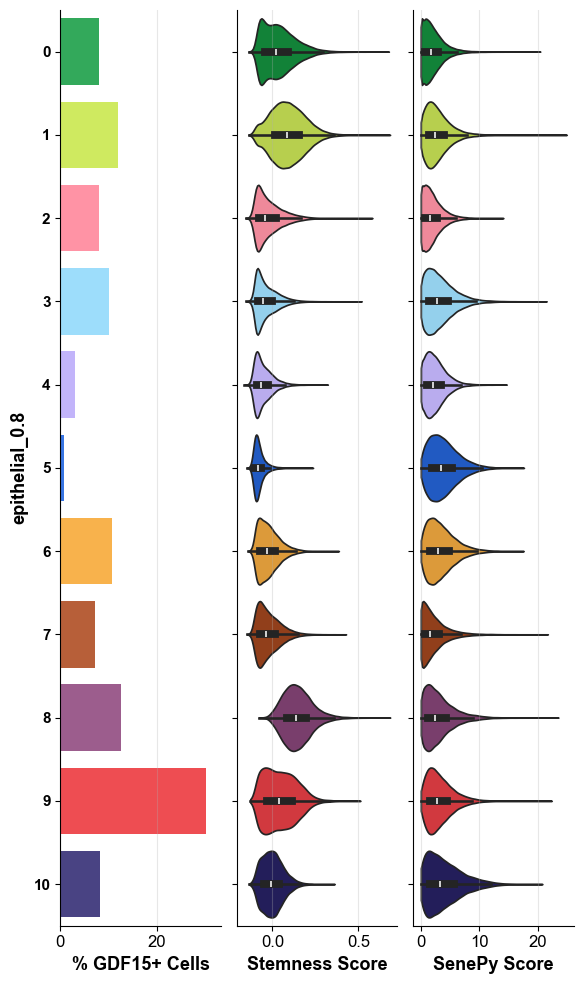

In [22]:
fig, axes, summary = plot_combined_stemness_senescence_analysis_violin(
    epi_adata,
    cluster_col=res,
    palette=cluster_colors,
    figsize= (6, 10)
)

fig.savefig(os.path.join(output_dir, "combo_stem_senesc_gdf15_violin_vertical.pdf"), dpi=300, bbox_inches="tight")


# marker genes

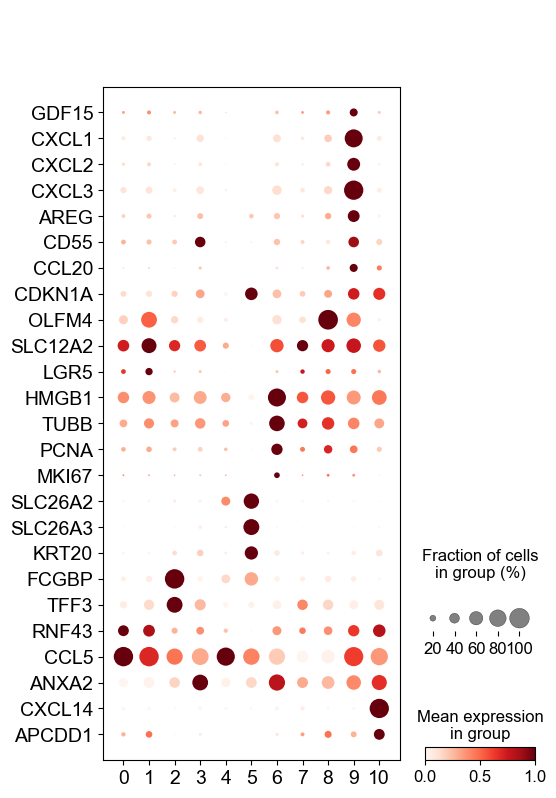

In [23]:
markers = ["GDF15","CXCL1","CXCL2","CXCL3","AREG","CD55","CCL20","CDKN1A","OLFM4","SLC12A2","LGR5","HMGB1","TUBB","PCNA","MKI67","SLC26A2","SLC26A3","KRT20","FCGBP","TFF3", "RNF43","CCL5","ANXA2","CXCL14","APCDD1"]

dp = sc.pl.dotplot(
    epi_adata,
    markers,
    groupby=res,
    standard_scale="var",
    return_fig=True,
    swap_axes=True,
)
dp.style(dot_edge_color="none")
ax_dict = dp.show(return_axes=True)

ax_dict["mainplot_ax"].tick_params(axis="both", labelsize=14)
ax_dict["mainplot_ax"].set_xticklabels(
    ax_dict["mainplot_ax"].get_xticklabels(), rotation=0, ha="center", fontsize=14
)

for ax_name, ax in ax_dict.items():
    if ax_name != "mainplot_ax":
        ax.tick_params(labelsize=12)
        if ax.get_title():
            ax.set_title(ax.get_title(), fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "markers_dotplot.pdf"), dpi=300, bbox_inches="tight")

plt.show()

# cluster composition by tissue

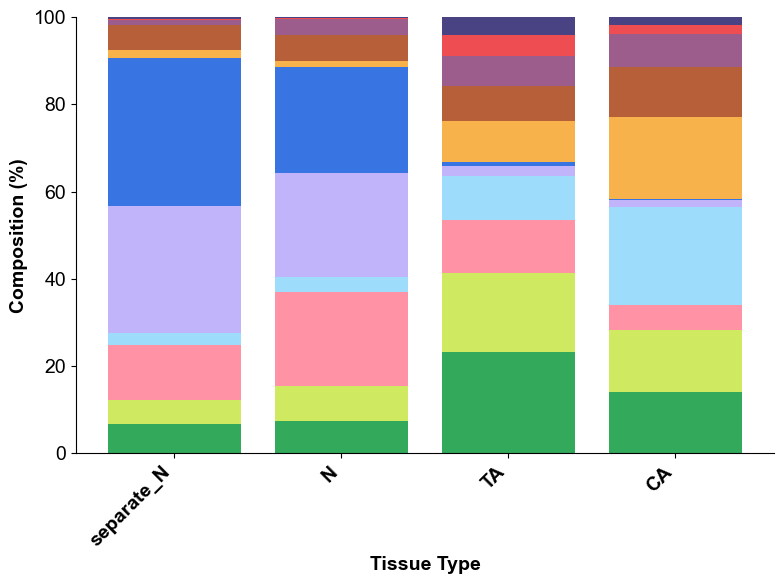

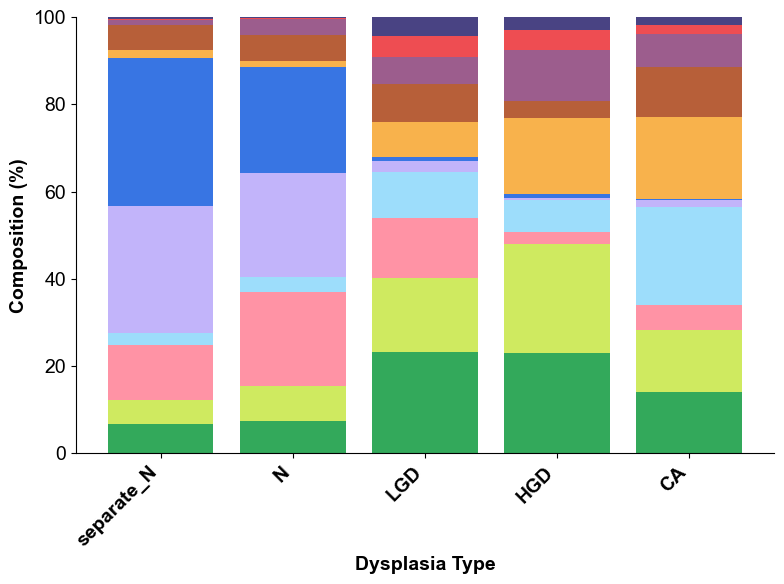

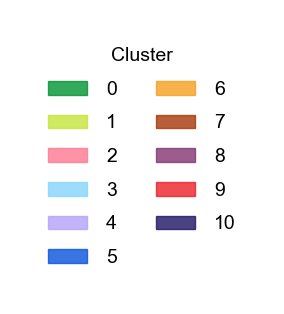

In [ ]:
def plot_cluster_composition_by_tissue(
    adata,
    cluster_col: str,
    cluster_palette: list = None,
    figsize: Tuple[int, int] = (8, 6),
):
    tissue_normal_split_order = ['separate_N', 'N', 'TA', 'CA', 'NA']
    clusters = sorted(adata.obs[cluster_col].astype(str).unique(), key=lambda x: int(x))
    if cluster_palette is None:
        cluster_colors = dict(zip(clusters, sns.color_palette("tab20", len(clusters))))
    elif isinstance(cluster_palette, list):
        cluster_colors = dict(zip(clusters, cluster_palette[:len(clusters)]))
    else:
        cluster_colors = cluster_palette

    def make_bar_plot(ax, col, order, xlabel):
        composition = pd.crosstab(
            adata.obs[col],
            adata.obs[cluster_col].astype(str),
            normalize='index'
        ) * 100
        available = [cat for cat in order if cat in composition.index]
        composition = composition.reindex(index=available, columns=clusters, fill_value=0)
        bottom = np.zeros(len(available))
        for cluster in clusters:
            ax.bar(range(len(available)), composition[cluster],
                   bottom=bottom, color=cluster_colors[cluster],
                   label=cluster, alpha=0.8)
            bottom += composition[cluster].values
        ax.set_ylabel('Composition (%)', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(available)))
        ax.set_xticklabels(available, rotation=45, ha='right', fontsize=14, fontweight='bold')
        ax.tick_params(axis='y', labelsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return composition

    fig1, ax1 = plt.subplots(figsize=figsize)
    composition_tissue_normal_split = make_bar_plot(
        ax1, 'tissue_type_cell_level_normal_split', tissue_normal_split_order, 'Tissue Type'
    )
    plt.tight_layout()
    plt.show()

    fig_legend, ax_legend = plt.subplots(figsize=(3, len(clusters) * 0.3))
    handles = [plt.Rectangle((0, 0), 1, 1, color=cluster_colors[c], alpha=0.8) for c in clusters]
    ax_legend.legend(handles, clusters, title="Cluster", fontsize=14,
                 title_fontsize=14, frameon=False, loc='center',
                 handletextpad=1.0, labelspacing=0.8, ncol=2)
    ax_legend.axis('off')
    plt.tight_layout()
    plt.show()

    return (
        {'fig1': fig1, 'fig_legend': fig_legend},
        {'ax1': ax1},
        {'tissue_normal_split_composition': composition_tissue_normal_split},
    )

figs, axes, compositions = plot_cluster_composition_by_tissue(
    epi_adata,
    cluster_col=res,
    cluster_palette=cluster_colors
)

figs['fig1'].savefig(os.path.join(output_dir, "tissue_type_composition_barplot.pdf"), dpi=300, bbox_inches="tight")
figs['fig_legend'].savefig(os.path.join(output_dir, "cluster_legend.pdf"), dpi=300, bbox_inches="tight")

### sccoda

In [25]:
import sccoda.util.cell_composition_data as dat
import sccoda.util.comp_ana as mod


I0000 00:00:1783629496.547738  743095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783629496.564900  743095 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783629512.956031  743095 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783629557.188036  743095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [26]:
# 1. Aggregate to core-level counts
core_counts = (
    epi_adata.obs
    .groupby(['core_id', 'tissue_type_cell_level_normal_split'])[res]
    .value_counts()
    .unstack(fill_value=0)
)

# Drop rows where total cell count is 0
core_counts = core_counts[core_counts.sum(axis=1) > 0]
core_counts.columns = core_counts.columns.astype(str)

In [28]:
# 2. Build scCODA AnnData
import anndata as ad

core_adata = ad.AnnData(
    X=core_counts.values,
    obs=core_counts.index.to_frame(index=False).rename(
        columns={core_counts.index.names[0]: 'core_id',
                 core_counts.index.names[1]: 'tissue_type'}
    ),
)
core_adata.var_names = core_counts.columns
core_adata.obs.index = core_adata.obs.index.astype(str)

In [ ]:
def get_credible_series(result, tissue_level):
    """
    Extract the credible-effects boolean Series for one non-reference
    tissue level from a fitted scCODA result, indexed by cell type only.
    """
    ce = result.credible_effects()  # MultiIndex: (Covariate, Cell Type) -> bool
    # Covariate names look like: "C(tissue_type, Treatment('N'))[T.TA]"
    covariate_names = ce.index.get_level_values(0).unique()
    match = [c for c in covariate_names if c.endswith(f"[T.{tissue_level}]")]
    if len(match) != 1:
        raise ValueError(
            f"Expected exactly one covariate matching level '{tissue_level}', "
            f"found {match} in {list(covariate_names)}"
        )
    sub = ce.loc[match[0]]          # Series indexed by Cell Type
    sub.index = sub.index.astype(str)
    return sub

# --- Reference tissue: separate_N ---
model_sep_n = mod.CompositionalAnalysis(
    core_adata,
    formula="C(tissue_type, Treatment('separate_N'))",
    reference_cell_type='7'
)
result_sep_n = model_sep_n.sample_hmc(num_results=20000, num_burnin=5000)
print("\n--- Reference tissue: separate_N ---")
print(result_sep_n.credible_effects())

# --- Reference tissue: N ---
model_n = mod.CompositionalAnalysis(
    core_adata,
    formula="C(tissue_type, Treatment('N'))",
    reference_cell_type='7'
)
result_n = model_n.sample_hmc(num_results=20000, num_burnin=5000)
print("\n--- Reference tissue: N ---")
print(result_n.credible_effects())

# --- Reference tissue: TA ---
model_ta = mod.CompositionalAnalysis(
    core_adata,
    formula="C(tissue_type, Treatment('TA'))",
    reference_cell_type='7'
)
result_ta = model_ta.sample_hmc(num_results=20000, num_burnin=5000)
print("\n--- Reference tissue: TA ---")
print(result_ta.credible_effects())

# --- Assemble all six pairwise comparisons from the three reference runs ---
comparisons = {
    'separate_N vs N':  get_credible_series(result_sep_n, 'N'),
    'separate_N vs TA': get_credible_series(result_sep_n, 'TA'),
    'separate_N vs CA': get_credible_series(result_sep_n, 'CA'),
    'N vs TA':          get_credible_series(result_n, 'TA'),
    'N vs CA':          get_credible_series(result_n, 'CA'),
    'TA vs CA':         get_credible_series(result_ta, 'CA'),
}
clusters = sorted(epi_adata.obs[res].astype(str).unique(), key=lambda x: int(x))
credible = pd.DataFrame(comparisons).loc[clusters]

if credible.isna().any().any():
    missing = credible.isna()
    raise ValueError(
        f"Missing credible-effect values detected:\n"
        f"{missing[missing.any(axis=1)]}"
    )

# Save so the plotting step doesn't require re-running HMC sampling
# credible.to_csv('sccoda_credible_effects.csv')

E0000 00:00:1783629611.790050  743095 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783629611.790725  755200 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1783629611.820975  743095 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783629611.821028  755200 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783629611.830210  743095 gpu_device.cc:2365] Cannot dlopen some GPU l

Zero counts encountered in data! Added a pseudocount of 0.5.


  0%|          | 0/20000 [00:00<?, ?it/s]I0000 00:00:1783629613.255815  755295 service.cc:153] XLA service 0x7c67f801e1d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783629613.255841  755295 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1783629613.305306  755295 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783629613.988381  755295 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [02:49<00:00, 117.85it/s]


MCMC sampling finished. (214.098 sec)
Acceptance rate: 57.9%

--- Reference tissue: separate_N ---
Covariate                                      Cell Type
C(tissue_type, Treatment('separate_N'))[T.CA]  0            False
                                               1             True
                                               2             True
                                               3            False
                                               4             True
                                               5             True
                                               6             True
                                               7            False
                                               8            False
                                               9            False
                                               10           False
C(tissue_type, Treatment('separate_N'))[T.N]   0            False
                                               1    

100%|██████████| 20000/20000 [02:47<00:00, 119.21it/s]


MCMC sampling finished. (211.064 sec)
Acceptance rate: 39.7%

--- Reference tissue: N ---
Covariate                                     Cell Type
C(tissue_type, Treatment('N'))[T.CA]          0            False
                                              1             True
                                              2             True
                                              3            False
                                              4             True
                                              5             True
                                              6             True
                                              7            False
                                              8            False
                                              9             True
                                              10           False
C(tissue_type, Treatment('N'))[T.TA]          0             True
                                              1            False
         

100%|██████████| 20000/20000 [02:47<00:00, 119.10it/s]


MCMC sampling finished. (211.452 sec)
Acceptance rate: 58.8%

--- Reference tissue: TA ---
Covariate                                      Cell Type
C(tissue_type, Treatment('TA'))[T.CA]          0            False
                                               1             True
                                               2            False
                                               3            False
                                               4            False
                                               5            False
                                               6             True
                                               7            False
                                               8            False
                                               9            False
                                               10           False
C(tissue_type, Treatment('TA'))[T.N]           0            False
                                               1            

NameError: name 'clusters' is not defined

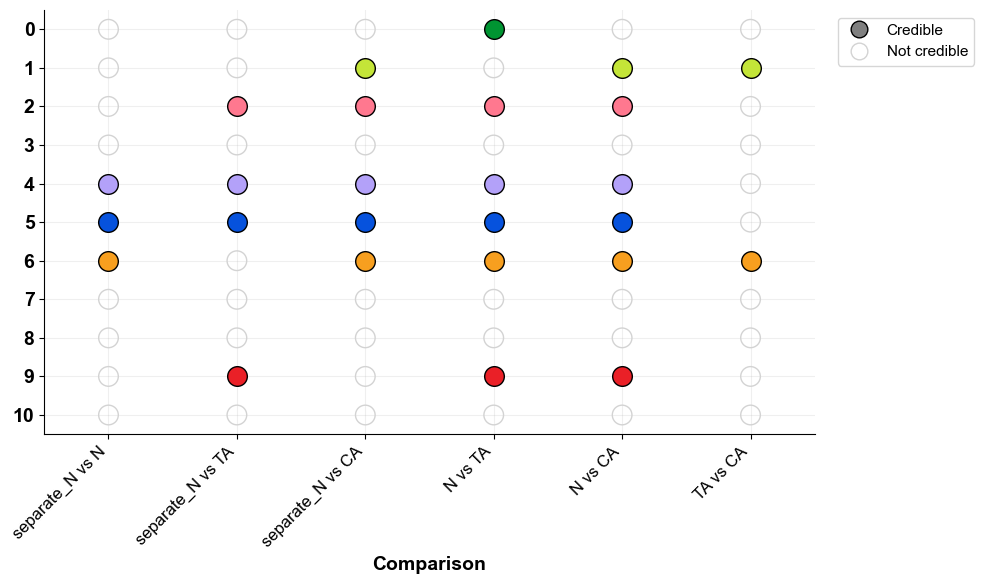

In [36]:

credible.index = credible.index.astype(str)  # match `clusters` dtype

fig, ax = plt.subplots(figsize=(10, 6))

for i, cluster in enumerate(clusters):
    for j, comp in enumerate(credible.columns):
        if credible.loc[cluster, comp]:
            ax.scatter(j, i, s=200, c=[cluster_colors[cluster]],
                       edgecolors='black', linewidth=1, zorder=3)
        else:
            ax.scatter(j, i, s=200, facecolors='none',
                       edgecolors='lightgray', linewidth=1, zorder=3)

ax.set_yticks(range(len(clusters)))
ax.set_yticklabels(clusters, fontsize=14, fontweight='bold')
ax.set_xticks(range(len(credible.columns)))
ax.set_xticklabels(credible.columns, rotation=45, ha='right', fontsize=12)
ax.set_xlim(-0.5, len(credible.columns) - 0.5)
ax.set_ylim(-0.5, len(clusters) - 0.5)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='both', alpha=0.2)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=12, markeredgecolor='black', label='Credible'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markersize=12, markeredgecolor='lightgray', label='Not credible'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), frameon=True, fontsize=11)

ax.set_xlabel('Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cluster_credibility_dotplot.pdf'), bbox_inches='tight')
plt.show()

### mann whitney

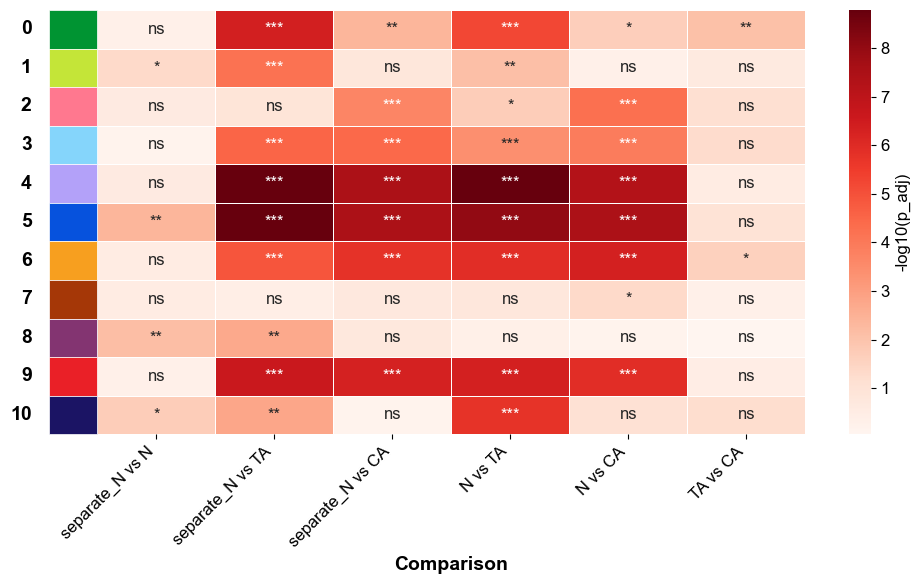

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

tissue_types = ['separate_N', 'N', 'TA', 'CA']
clusters = sorted(epi_adata.obs[res].astype(str).unique(), key=lambda x: int(x))

# ── 1. Overall chi-square ────────────────────────────────────────────────────
contingency = pd.crosstab(
    epi_adata.obs['tissue_type_cell_level_normal_split'],
    epi_adata.obs[res].astype(str)
)
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Overall chi-square: chi2={chi2:.2f}, p={p:.2e}")

# ── 2. Pairwise chi-square with BH correction ───────────────────────────────
pairwise_results = []
for t1, t2 in combinations(tissue_types, 2):
    sub = contingency.loc[[t1, t2]]
    chi2_pair, p_pair, _, _ = chi2_contingency(sub)
    pairwise_results.append({'tissue_1': t1, 'tissue_2': t2, 'chi2': chi2_pair, 'p': p_pair})

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df['p_adj'] = multipletests(pairwise_df['p'], method='fdr_bh')[1]
print(pairwise_df)

# ── 3. Core-level Mann-Whitney per cluster per pair ──────────────────────────
core_contingency = epi_adata.obs.groupby(
    ['core_id', 'tissue_type_cell_level_normal_split']
)[res].value_counts().unstack(fill_value=0)
core_contingency = core_contingency[core_contingency.sum(axis=1) > 0]

core_props = core_contingency.div(core_contingency.sum(axis=1), axis=0)
core_props['tissue_type'] = core_contingency.index.get_level_values(1)

cluster_results = []
for t1, t2 in combinations(tissue_types, 2):
    for cluster in clusters:
        group1 = core_props[core_props['tissue_type'] == t1][cluster]
        group2 = core_props[core_props['tissue_type'] == t2][cluster]
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            cluster_results.append({
                'tissue_1': t1, 'tissue_2': t2,
                'cluster': cluster, 'U': stat, 'p': p
            })

cluster_df = pd.DataFrame(cluster_results)
cluster_df['p_adj'] = multipletests(cluster_df['p'], method='fdr_bh')[1]
print(cluster_df.to_string())

# ── 4. Significance heatmap ──────────────────────────────────────────────────
sig_matrix = cluster_df.pivot_table(
    index='cluster', columns=['tissue_1', 'tissue_2'], values='p_adj'
)

def sig_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return 'ns'

sig_labels = sig_matrix.applymap(sig_label)

sig_matrix.columns = [f'{t1} vs {t2}' for t1, t2 in sig_matrix.columns]
sig_labels.columns = sig_matrix.columns

sort_order = sorted(sig_matrix.index, key=lambda x: int(x))
sig_matrix = sig_matrix.loc[sort_order]
sig_labels = sig_labels.loc[sort_order]

col_order = [
    'separate_N vs N', 'separate_N vs TA', 'separate_N vs CA',
    'N vs TA', 'N vs CA', 'TA vs CA'
]
sig_matrix = sig_matrix[col_order]
sig_labels = sig_labels[col_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    -np.log10(sig_matrix.astype(float)),
    annot=sig_labels, fmt='', cmap='Reds',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '-log10(p_adj)'},
    ax=ax, yticklabels=False
)
ax.tick_params(axis='y', left=False)
ax.set_ylabel('')

fig.canvas.draw()
bbox = ax.get_window_extent()
ncols = len(col_order)
nrows = len(sort_order)
data_units_per_pixel_x = ncols / bbox.width
row_height_px = bbox.height / nrows
square_width = row_height_px * data_units_per_pixel_x

for i, cluster in enumerate(sort_order):
    color = cluster_colors[cluster]
    rect = mpatches.Rectangle(
        (-square_width, i), square_width, 1,
        facecolor=color, edgecolor='white', linewidth=0.5, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(-square_width - 0.15, i + 0.5, cluster, ha='right', va='center',
            fontsize=14, fontweight='bold', clip_on=False)

ax.set_xlabel('Comparison', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "tissue_type_composition_barplot.pdf"), bbox_inches='tight', dpi=300)
plt.show()

# UMAPS

2026-04-01 15:05:13 | [INFO] maxp pruned
2026-04-01 15:05:13 | [INFO] LTSH dropped
2026-04-01 15:05:13 | [INFO] cmap pruned
2026-04-01 15:05:13 | [INFO] kern pruned
2026-04-01 15:05:13 | [INFO] post pruned
2026-04-01 15:05:13 | [INFO] PCLT dropped
2026-04-01 15:05:13 | [INFO] JSTF dropped
2026-04-01 15:05:13 | [INFO] DSIG dropped
2026-04-01 15:05:13 | [INFO] GSUB pruned
2026-04-01 15:05:13 | [INFO] glyf pruned
2026-04-01 15:05:13 | [INFO] Added gid0 to subset
2026-04-01 15:05:13 | [INFO] Added first four glyphs to subset
2026-04-01 15:05:13 | [INFO] Closing glyph list over 'GSUB': 18 glyphs before
2026-04-01 15:05:13 | [INFO] Glyph names: ['.notdef', '.null', 'S', 'c', 'e', 'eight', 'four', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'six', 'space', 'two', 'y', 'zero']
2026-04-01 15:05:13 | [INFO] Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 23, 25, 27, 54, 70, 72, 81, 82, 83, 85, 92]
2026-04-01 15:05:13 | [INFO] Closed glyph list over 'GSUB': 18 glyphs after
2026-04-01 15:05:13 | [INFO] G

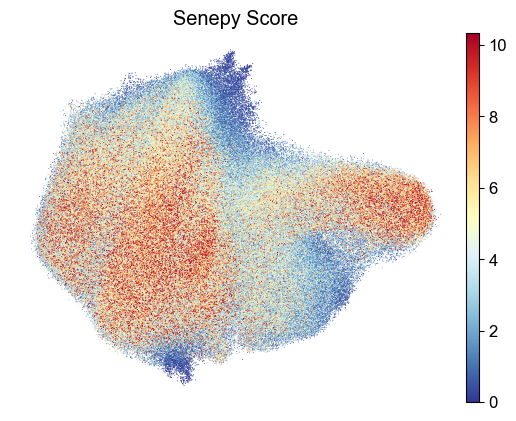

2026-04-01 15:05:20 | [INFO] maxp pruned
2026-04-01 15:05:20 | [INFO] LTSH dropped
2026-04-01 15:05:20 | [INFO] cmap pruned
2026-04-01 15:05:20 | [INFO] kern pruned
2026-04-01 15:05:20 | [INFO] post pruned
2026-04-01 15:05:20 | [INFO] PCLT dropped
2026-04-01 15:05:20 | [INFO] JSTF dropped
2026-04-01 15:05:20 | [INFO] DSIG dropped
2026-04-01 15:05:20 | [INFO] GSUB pruned
2026-04-01 15:05:20 | [INFO] glyf pruned
2026-04-01 15:05:20 | [INFO] Added gid0 to subset
2026-04-01 15:05:20 | [INFO] Added first four glyphs to subset
2026-04-01 15:05:20 | [INFO] Closing glyph list over 'GSUB': 19 glyphs before
2026-04-01 15:05:20 | [INFO] Glyph names: ['.notdef', '.null', 'S', 'c', 'e', 'five', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'space', 't', 'two', 'zero']
2026-04-01 15:05:20 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 24, 54, 70, 72, 80, 81, 82, 85, 86, 87, 237]
2026-04-01 15:05:20 | [INFO] Closed glyph list over 'GSUB': 19 glyphs after
2026-04-01 15:05:

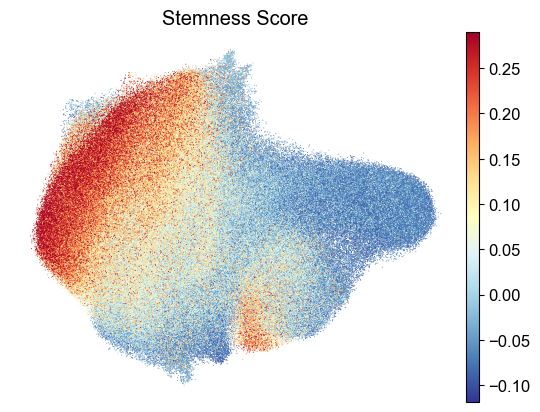

In [77]:
sc.settings._vector_friendly = True
ax = sc.pl.umap(epi_adata, color="senepy_intestine_epi_0", cmap="RdYlBu_r", vmax="p99", vmin="p1",size=2, show=False, title="Senepy Score")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "senepy_score_umap.pdf"), dpi=300, bbox_inches="tight")

plt.show()


ax = sc.pl.umap(epi_adata, color="stemness_score", cmap="RdYlBu_r", vmax="p99", vmin="p1",size=2, show=False, title="Stemness Score")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "stemness_score_umap.pdf"), dpi=300, bbox_inches="tight")

plt.show()

sc.settings._vector_friendly = False

# Neighborhood analysis

In [ ]:
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.sparse import block_diag

# ── 2. Per-tissue neighborhood enrichment ────────────────────────────────────
tissue_types = ['separate_N', 'N', 'TA', 'CA']
MIN_CELLS_PER_CLUSTER = 0
MIN_CELLS_PER_CORE = 5

tissue_results = {}

for tissue in tissue_types:
    print(f"\nProcessing tissue type: {tissue}")
    tissue_adata = epi_adata[epi_adata.obs['tissue_type_cell_level_normal_split'] == tissue].copy()

    cluster_counts = tissue_adata.obs['epithelial_0.8'].value_counts()
    valid_clusters = cluster_counts[cluster_counts >= MIN_CELLS_PER_CLUSTER].index.tolist()
    removed_clusters = cluster_counts[cluster_counts < MIN_CELLS_PER_CLUSTER].index.tolist()
    if removed_clusters:
        print(f"  Removing clusters with < {MIN_CELLS_PER_CLUSTER} cells: {removed_clusters}")

    tissue_adata = tissue_adata[tissue_adata.obs['epithelial_0.8'].isin(valid_clusters)].copy()
    if tissue_adata.n_obs == 0:
        print(f"  No valid cells for {tissue}, skipping.")
        continue

    core_adatas = []
    for core in sorted(tissue_adata.obs['core_id'].unique()):
        core_mask = tissue_adata.obs['core_id'] == core
        core_adata = tissue_adata[core_mask].copy()
        if core_mask.sum() < MIN_CELLS_PER_CORE:
            continue
        sq.gr.spatial_neighbors(core_adata, coord_type="generic", spatial_key="spatial", delaunay=True)
        core_adatas.append(core_adata)

    if len(core_adatas) == 0:
        print(f"  No valid cores for {tissue}, skipping.")
        continue

    connectivities = block_diag([ca.obsp['spatial_connectivities'] for ca in core_adatas], format='csr')
    distances = block_diag([ca.obsp['spatial_distances'] for ca in core_adatas], format='csr')

    core_order = np.concatenate([
        np.where(tissue_adata.obs['core_id'] == ca.obs['core_id'].iloc[0])[0]
        for ca in core_adatas
    ])
    reorder = np.argsort(core_order)
    connectivities = connectivities[reorder][:, reorder]
    distances = distances[reorder][:, reorder]

    tissue_adata.obsp['spatial_connectivities'] = connectivities
    tissue_adata.obsp['spatial_distances'] = distances
    tissue_adata.uns['spatial_neighbors'] = {
        'connectivities_key': 'spatial_connectivities',
        'distances_key': 'spatial_distances',
        'params': {'coord_type': 'generic', 'delaunay': True}
    }

    local_clusters = sorted(tissue_adata.obs['epithelial_0.8'].unique(), key=lambda x: int(x))
    tissue_adata.obs['epithelial_0.8'] = pd.Categorical(
        tissue_adata.obs['epithelial_0.8'], categories=local_clusters, ordered=True
    )

    sq.gr.nhood_enrichment(tissue_adata, cluster_key="epithelial_0.8")
    tissue_results[tissue] = tissue_adata

valid_tissues = [t for t in tissue_types if t in tissue_results]
all_clusters_global = sorted(
    set().union(*[set(tissue_results[t].obs['epithelial_0.8'].unique()) for t in valid_tissues]),
    key=lambda x: int(x)
)
print(f"\nGlobal cluster order: {all_clusters_global}")


def get_enrichment_df(adata, global_clusters):
    zscore = adata.uns['epithelial_0.8_nhood_enrichment']['zscore']
    local_clusters = adata.obs['epithelial_0.8'].cat.categories.tolist()
    df = pd.DataFrame(zscore, index=local_clusters, columns=local_clusters)
    df = df.reindex(index=global_clusters, columns=global_clusters)
    return df

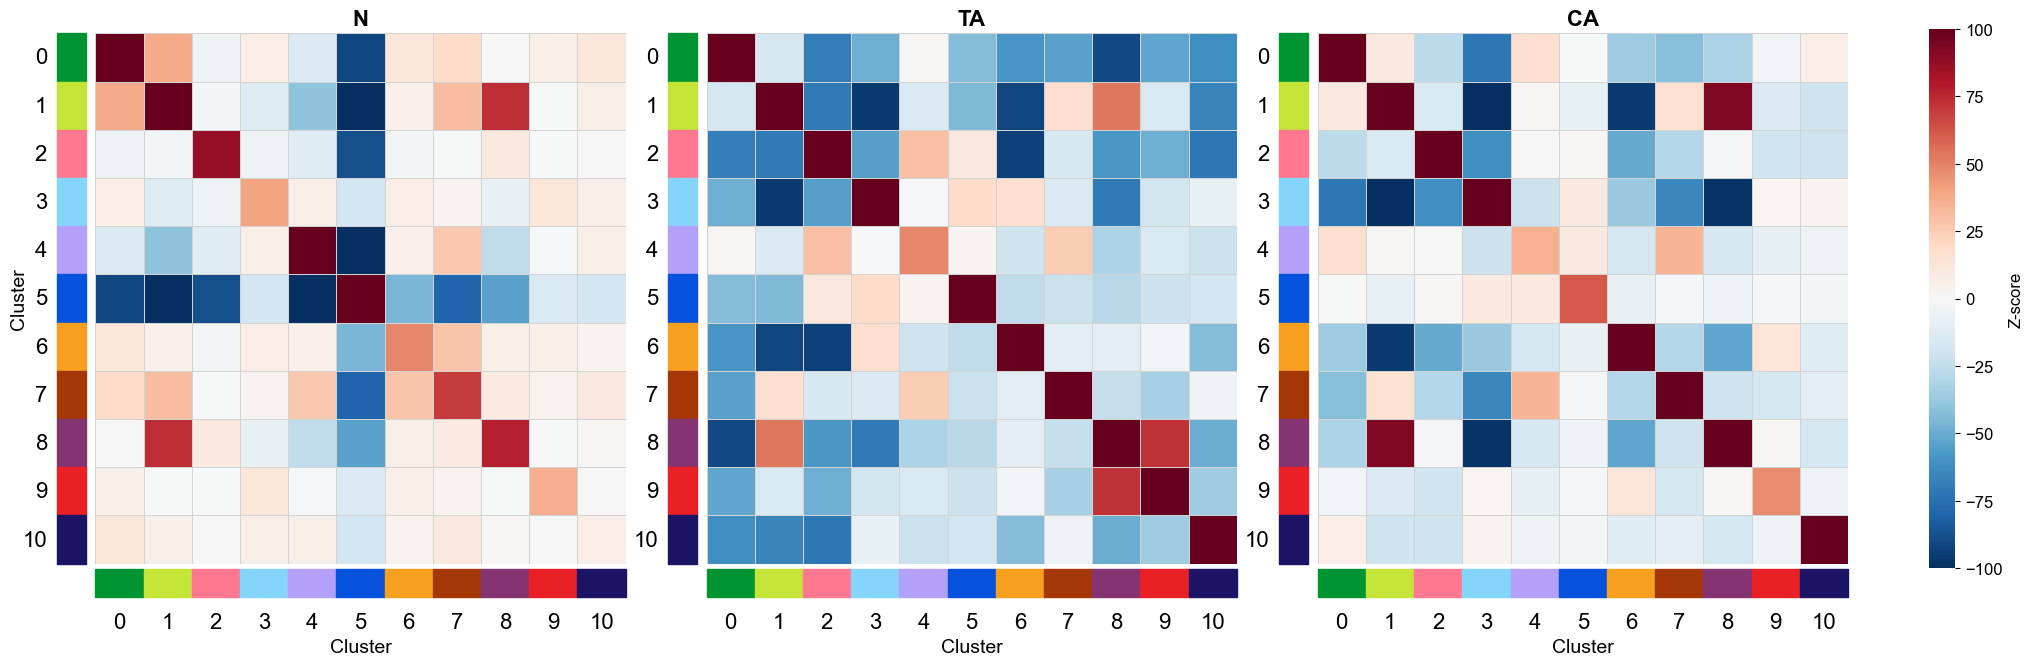

In [33]:
cluster_colors = cluster_colors

# --- Define merged tissue groups: (display_name, [keys_to_average]) ---
combined_tissues = [
    ("N", ["N", "separate_N"]),
    ("TA", ["TA"]),
    ("CA", ["CA"]),
]
# Filter out any keys not present in tissue_results
combined_tissues = [
    (name, [k for k in keys if k in tissue_results])
    for name, keys in combined_tissues
]

n_tissues = len(combined_tissues)  # 3
widths = [1] * n_tissues + [0.05]
fig, axes_all = plt.subplots(1, n_tissues + 1, figsize=(8 * n_tissues, 7),
                              gridspec_kw={'width_ratios': widths})
axes = axes_all[:n_tissues]
cbar_ax = axes_all[-1]
vmin, vmax = -100, 100
n_clusters = len(all_clusters_global)

for idx, (ax, (display_name, tissue_keys)) in enumerate(zip(axes, combined_tissues)):
    # Average enrichment DFs across keys in this group
    dfs = [get_enrichment_df(tissue_results[tk], all_clusters_global) for tk in tissue_keys]
    if len(dfs) > 1:
        df = pd.concat(dfs).groupby(level=0).mean()
        df = df.reindex(index=dfs[0].index, columns=dfs[0].columns)
    else:
        df = dfs[0]

    sns.heatmap(
        df,
        ax=ax,
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        square=True,
        linewidths=0.5,
        linecolor='lightgray',
        cbar=(idx == n_tissues - 1),
        cbar_ax=cbar_ax if (idx == n_tissues - 1) else None,
        cbar_kws={'label': 'Z-score'} if (idx == n_tissues - 1) else {},
        annot=False,
        mask=df.isna()
    )
    ax.set_title(display_name, fontsize=16, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=14, labelpad=50)
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', length=0)

    # Color swatches + labels on y-axis (left)
    for i, label in enumerate(all_clusters_global):
        color = cluster_colors.get(str(label), 'grey')
        ax.add_patch(plt.Rectangle((-0.8, i), 0.6, 1, color=color, clip_on=False))
        ax.text(-1.0, i + 0.5, str(label), ha='right', va='center', fontsize=16, clip_on=False)

    # Color swatches + labels on x-axis (bottom)
    for i, label in enumerate(all_clusters_global):
        color = cluster_colors.get(str(label), 'grey')
        ax.add_patch(plt.Rectangle((i, n_clusters + 0.1), 1, 0.6, color=color, clip_on=False))
        ax.text(i + 0.5, n_clusters + 1.0, str(label), ha='center', va='top', fontsize=16, clip_on=False)

# Single "Cluster" y-axis label on the far left
axes[0].set_ylabel('Cluster', fontsize=14, labelpad=45)

plt.subplots_adjust(wspace=0.2)
plt.savefig(os.path.join(output_dir, "neighborhood_matrices_by_tissue_type.pdf"), dpi=300, bbox_inches="tight")
plt.show()